# Process Annotated Data
Translate Label Studio JSON files to a format for ML

In [1]:
import json
import ast
from datetime import datetime
from collections import defaultdict
from typing import Any, Dict
from dataclasses import dataclass

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from transformers import AutoTokenizer

In [ ]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent / "src"))

from common.paths import RAW, PROCESSED
from common.graph_helpers import analyze_category_distribution_from_dict, plot_cooccurrence_heatmap
from eval.evaluators import SpanEvaluator
from common.logging import setup_logger

ModuleNotFoundError: No module named 'common'

In [ ]:
@dataclass
class Config:
    logger = setup_logger('preprocessing.process_annotated_data')
    ANNOTATED_DATA_PATH = RAW / "annotations" / "annotated-gold-standard.json"
    TAXONOMY_PATH = PROCESSED / "taxonomy_autogen_v2.csv"

    OUTPUT_PATH = PROCESSED / "gold_standard.json"
    TAXONOMY_V3_PATH = PROCESSED / "taxonomy_autogen_v3.csv"

    OUTPUT_PATH_DOC_LEVEL = PROCESSED / "gold_standard_doc_level.json"
    OUTPUT_PATH_LABEL_MAPPING = PROCESSED / "label_mapping.json"

    RANDOM_STATE = 42
    ENTITY_LABELS = {"Person_Name", "Person_Role", "Person_Pronoun"}
    CAT_LABELS = []

config = Config()

## Import Data

In [ ]:
with open(config.ANNOTATED_DATA_PATH, 'r', encoding='utf-8') as f:
    data = json.load(f)

len(data)

2000

In [ ]:
taxonomy = pd.read_csv(config.TAXONOMY_PATH)
taxonomy.head(5)

,high_level_category,category_description,values_hint,cat_label,regex
0,Care,Care experienced,"['Care leaver', 'Care experienced (under 25)']",care_care_experienced,\bcare experienced\b|\bcare leaver\b|\baged ou...
1,Care,Care setting,"['Fostered', 'Social care']",care_care_setting,\bfostered\b|\bfoster care\b|\bfoster placemen...
2,Care,Has caring responsibility,"['Formal', 'Informal']",care_has_caring_responsibility,\bformal carer\b|\bregistered carer\b|\bcarer....
3,Care,Social care involvement,"['Adult Social Care', ""Children's Social Care""]",care_social_care_involvement,\bsocial care\b|\bcare package\b|\bcare plan\b...
4,Cautions,ASBO or injunction obtained,"['ASBO', 'Injunction']",cautions_asbo_or_injunction_obtained,\bASBO\b|\binjunction\b|\bcivil injunction\b|\...


## Format

Strip out Label Studio Metadata, make sure spans are aligned with words.

In [ ]:
config.CAT_LABELS = set(taxonomy.cat_label.values.tolist())

In [ ]:
def clean_span(text: str, start: int, end: int):
    """
    Validates and cleans Label Studio character offsets.
    Expands span boundaries if they split a word.
    """
    if start < 0 or end > len(text) or start >= end:
        return None

    # Expand backwards if we are in the middle of a word
    while start > 0 and text[start - 1].isalnum():
        start -= 1

    # Expand forwards if we are in the middle of a word
    while end < len(text) and text[end].isalnum():
        end += 1

    span_text = text[start:end]

    # Remove accidental whitespace
    cleaned = span_text.strip()

    if not cleaned:
        return None

    leading_whitespace = len(span_text) - len(span_text.lstrip())

    new_start = start + leading_whitespace
    new_end = new_start + len(cleaned)

    return {
        "text": cleaned,
        "start": new_start,
        "end": new_end
    }

In [ ]:
def extract_annotations(task: Dict[str, Any]) -> Dict[str, Any] | None:
    '''
    Extract annotations from label studio. Strip out irrelevant metadata, output in a clean format.
    Output format: {id: uuid (note id), label_studio_id: int, annotation_date: datetime, text: str (note text), needs: list(dict), persons: list(dict), relations: list(dict)}
    '''
    
    id = task["data"]["id"]
    text = task["data"]["note_content"]

    # 2. Get annotations from array
    task_annotations = task["annotations"]
    if len(task_annotations) == 0:
        print(f"Note with id {id} has no annotations.")
        return None
    else:
        # Fix accidental duplicated annotations - choose earliest one
        annotation = min(task_annotations, key=lambda x: datetime.strptime(x["created_at"], "%Y-%m-%dT%H:%M:%S.%fZ"))
    
    annotation_date = datetime.strptime(annotation["created_at"], "%Y-%m-%dT%H:%M:%S.%fZ")
    labels = annotation["result"]

    # 3. Handle annotations
    needs = []
    persons = []
    relations = []
    seen_ids = set()

    # 3.1. Handle text labels first
    for l in labels:
        if l["type"] != "labels":
            continue

        entity_id = l["id"]
        label = l["value"]["labels"][0]
        original_start = l["value"]["start"]
        original_end = l["value"]["end"]

        # Check span is correct 
        span = clean_span(text, original_start, original_end)
        if span is None:
            print(f"Skipping invalid span. Entity ID: {entity_id}, Note ID: {id}")
            continue

        clean_text = span["text"]
        new_start = span["start"]
        new_end = span["end"]

        # Save to seen_ids and relevant list
        if entity_id not in seen_ids:
            seen_ids.add(entity_id)
        
        item = {"id": entity_id, "text": clean_text, "start": new_start, "end": new_end, "label": label}

        # Needs
        if l["from_name"] == "need_labels" and label in config.CAT_LABELS:
            needs.append(item)
        # Persons
        elif l["from_name"] == "entity_labels" and label in config.ENTITY_LABELS:
            persons.append(item)
        else:
            print(f"Skipping unknown label: type: '{l['from_name']}', label: '{label}' in note '{id}'")

    # 3.2. Handle relations second (make sure all IDs exist)
    for l in labels:
        if l["type"] != "relation":
            continue

        from_id = l["from_id"]
        to_id = l["to_id"]

        if from_id in seen_ids and to_id in seen_ids:
            relations.append({"from": from_id, "to": to_id})
        else:
            print(f"Skipping relation between unknown id(s): from: '{from_id}', to: '{to_id}' in note '{id}'")

    return {
        "id": id,
        "label_studio_id": task['id'],
        "annotation_date": annotation_date,
        "text": text,
        "needs": needs,
        "persons": persons,
        "relations": relations,
    }

In [ ]:
records = [extract_annotations(task) for task in data]

In [ ]:
records[1]

{'id': '685524bb-94d4-4f08-8669-0e78df744c0c',
 'label_studio_id': 28101,
 'annotation_date': datetime.datetime(2026, 5, 19, 15, 18, 59, 455700),
 'text': '[Category: tenureManagement] Welfare check and tenancy audit completed I visited the tenant in his property following his request for me to come over and assess the toilet in his property. I used the opportunity to complete a tenancy audit and I observed that he is a hoarder with so many items in nearly all the rooms. The toilet seat has broken and the toilet is as dark as charcoal.',
 'needs': [{'id': '3aefb716',
   'text': 'hoarder',
   'start': 268,
   'end': 275,
   'label': 'housing_conditions_hoarding'},
  {'id': '99751da7',
   'text': 'so many items in nearly all the rooms',
   'start': 281,
   'end': 318,
   'label': 'housing_conditions_hoarding'},
  {'id': '354b3b37',
   'text': 'toilet seat has broken',
   'start': 324,
   'end': 346,
   'label': 'property_level_disrepair_damp_mould'},
  {'id': 'c8515bee',
   'text': 'toil

## Find Duplicates (on note text), calculate agreement.

In [ ]:
# Group records by exact text match
grouped = defaultdict(list)
for record in records:
    grouped[record["text"]].append(record)
len(grouped)

1908

In [ ]:
y_true_docs = []
y_pred_docs = []
all_labels = set()

for note_content, duplicates in grouped.items():
    if len(duplicates) == 1:
        continue

    # If duplicated, choose latest annotation as 'ground truth'
    duplicates.sort(key=lambda x: x['annotation_date'], reverse=True)
    new = duplicates[0]
    old = duplicates[1] # Ignore multiple duplications - will mess up the y_true / y_preds function.

    old_spans = [
            (span["start"], span["end"], span["label"])
            for span in old.get('needs', []) + old.get('persons', [])
        ]
    new_spans = [
        (span["start"], span["end"], span["label"])
        for span in new.get('needs', []) + new.get('persons', [])
    ]

    y_true_docs.append(old_spans)
    y_pred_docs.append(new_spans)

    for _, _, label in old_spans + new_spans:
        all_labels.add(label)

print(len(y_true_docs), len(y_pred_docs))

88 88


In [ ]:
evaluator = SpanEvaluator(all_labels=all_labels, logger=config.logger)
results = evaluator.evaluate(y_true_docs, y_pred_docs)
evaluator.print_report(results, title="INTRA-ANNOTATOR AGREEMENT REPORT (CURRENT VS PAST SELF)")

2026-06-29 17:40:16,278 | INFO | ========================================================================================================================
2026-06-29 17:40:16,279 | INFO | INTRA-ANNOTATOR AGREEMENT REPORT (CURRENT VS PAST SELF)
2026-06-29 17:40:16,279 | INFO | ========================================================================================================================
2026-06-29 17:40:16,279 | INFO | Label                                         | Loose F1        | Strict F1       | IoU>=0.3 F1     | IoU>=0.5 F1     | IoU>=0.7 F1     | IoU>=0.9 F1     | Delta(S-L)
2026-06-29 17:40:16,280 | INFO | care_care_setting                             | 1.000           | 1.000           | 1.000           | 1.000           | 1.000           | 1.000           | 0.000
2026-06-29 17:40:16,280 | INFO | care_has_caring_responsibility                | 0.769           | 0.769           | 0.769           | 0.769           | 0.769           | 0.769           | 0.000
2026-06-29 17

In [ ]:
results

{'per_label': {'care_care_setting': {'loose': {'p': 1.0,
    'r': 1.0,
    'f1': 1.0,
    'tp': 4,
    'fp': 0,
    'fn': 0},
   'strict': {'p': 1.0, 'r': 1.0, 'f1': 1.0, 'tp': 4, 'fp': 0, 'fn': 0},
   'iou_0.3': {'p': 1.0, 'r': 1.0, 'f1': 1.0, 'tp': 4, 'fp': 0, 'fn': 0},
   'iou_0.5': {'p': 1.0, 'r': 1.0, 'f1': 1.0, 'tp': 4, 'fp': 0, 'fn': 0},
   'iou_0.7': {'p': 1.0, 'r': 1.0, 'f1': 1.0, 'tp': 4, 'fp': 0, 'fn': 0},
   'iou_0.9': {'p': 1.0, 'r': 1.0, 'f1': 1.0, 'tp': 4, 'fp': 0, 'fn': 0}},
  'care_has_caring_responsibility': {'loose': {'p': 0.7142857142857143,
    'r': 0.8333333333333334,
    'f1': 0.7692307692307692,
    'tp': 5,
    'fp': 2,
    'fn': 1},
   'strict': {'p': 0.7142857142857143,
    'r': 0.8333333333333334,
    'f1': 0.7692307692307692,
    'tp': 5,
    'fp': 2,
    'fn': 1},
   'iou_0.3': {'p': 0.7142857142857143,
    'r': 0.8333333333333334,
    'f1': 0.7692307692307692,
    'tp': 5,
    'fp': 2,
    'fn': 1},
   'iou_0.5': {'p': 0.7142857142857143,
    'r': 0.83333

check for overalpping spans

In [ ]:
from collections import defaultdict
from itertools import combinations
from pathlib import Path

total_docs = len(records)
docs_with_overlaps = 0
total_overlapping_pairs = 0

# Track which label pairs overlap most frequently: {(labelA, labelB): count}
overlap_pairs_counts = defaultdict(int)

for idx, record in enumerate(records):
    entities = record.get("needs", []) + record.get("persons", [])
    if not entities:
        continue
        
    doc_has_overlap = False
    
    # Compare every entity with every other entity in the same document
    for ent1, ent2 in combinations(entities, 2):
        start1, end1 = ent1["start"], ent1["end"]
        start2, end2 = ent2["start"], ent2["end"]
        
        # Check for character span intersection
        if max(start1, start2) < min(end1, end2):
            total_overlapping_pairs += 1
            doc_has_overlap = True
            
            # Sort labels alphabetically to avoid duplicate (A,B) and (B,A) entries
            lbl_pair = tuple(sorted([ent1["label"], ent2["label"]]))
            overlap_pairs_counts[lbl_pair] += 1
            
    if doc_has_overlap:
        docs_with_overlaps += 1

print("=" * 70)
print(f"OVERLAP DIAGNOSTIC REPORT:")
print("=" * 70)
print(f"Total Documents Evaluated: {total_docs}")
print(f"Documents containing overlaps: {docs_with_overlaps} ({docs_with_overlaps/total_docs*100:.1f}%)")
print(f"Total structural overlap collisions found: {total_overlapping_pairs}")
print("-" * 70)

if total_overlapping_pairs > 0:
    print("TOP 10 CROSS-LABEL COLLISION PAIRS (Why BIO tagging failed here):")
    print("-" * 70)
    sorted_pairs = sorted(overlap_pairs_counts.items(), key=lambda x: x[1], reverse=True)
    print(f"{'Label A':<35} | {'Label B':<35} | {'Count':<5}")
    print("-" * 70)
    for (lbl1, lbl2), count in sorted_pairs[:10]:
        print(f"{lbl1:<35} | {lbl2:<35} | {count:<5}")
else:
    print("Clean run! No overlapping spans found in this file.")
print("=" * 70)

OVERLAP DIAGNOSTIC REPORT:
Total Documents Evaluated: 2000
Documents containing overlaps: 408 (20.4%)
Total structural overlap collisions found: 591
----------------------------------------------------------------------
TOP 10 CROSS-LABEL COLLISION PAIRS (Why BIO tagging failed here):
----------------------------------------------------------------------
Label A                             | Label B                             | Count
----------------------------------------------------------------------
person_ref                          | safety_risk_antisocial_behaviour    | 67   
person_ref                          | person_ref                          | 59   
life_events_temporary               | person_ref                          | 57   
care_has_caring_responsibility      | person_ref                          | 48   
person_ref                          | reasonable_adjustments_communication_needs | 45   
care_social_care_involvement        | person_ref                         

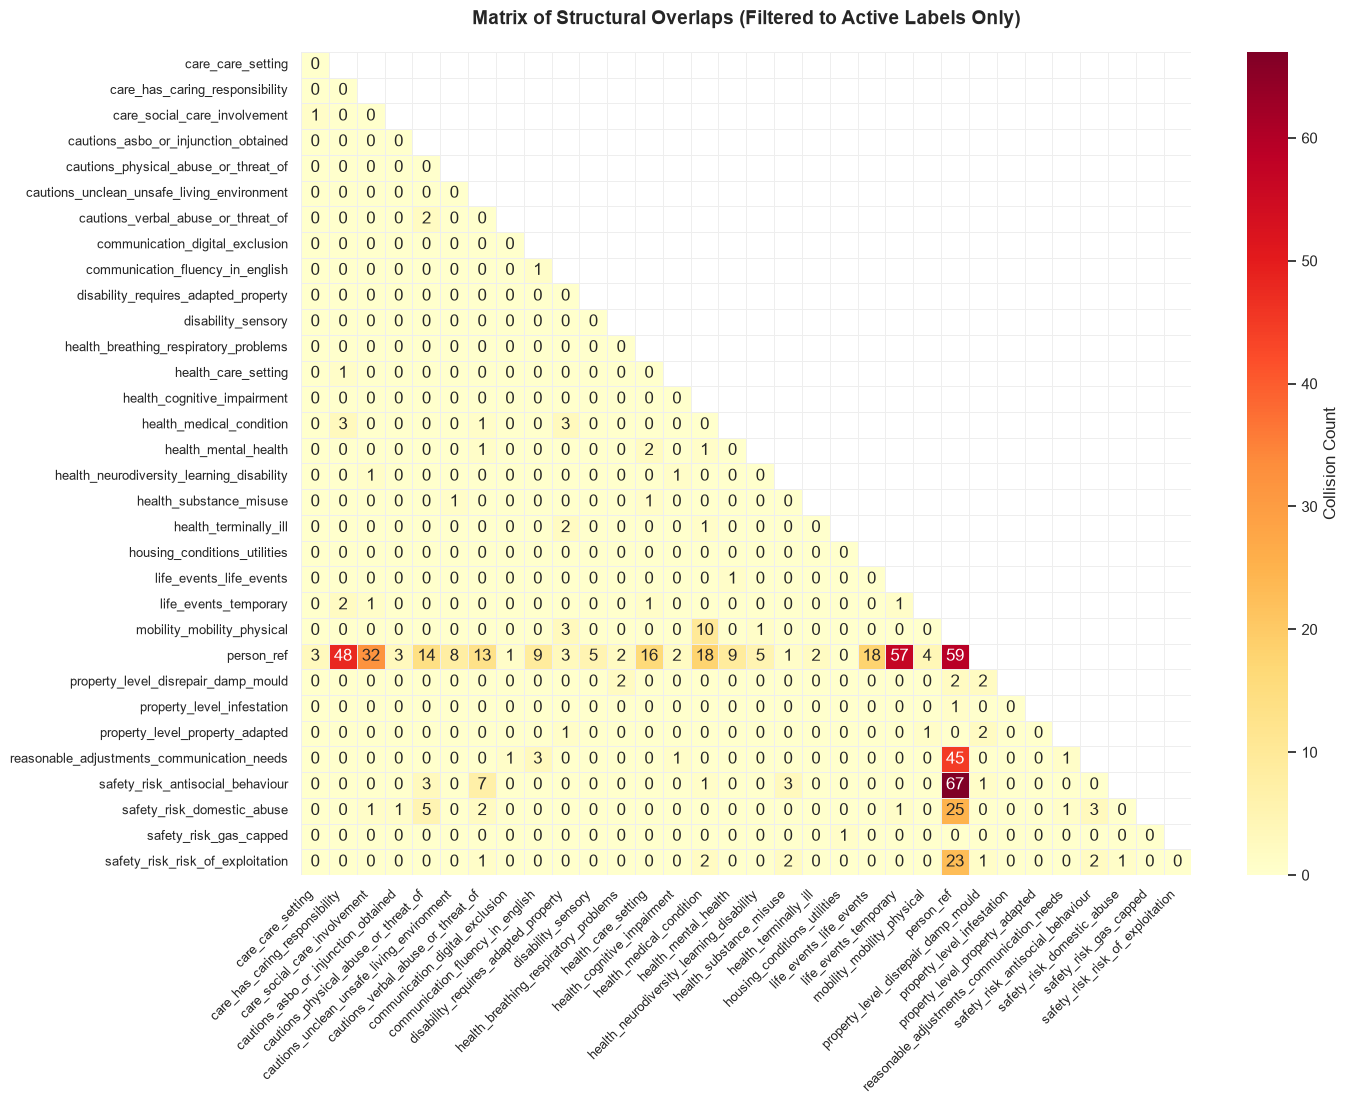


### Complete Cross-Label Overlap Matrix
Use this table to trace exactly how often Label 1 (Rows) intersects with Label 2 (Columns).



,care_care_setting,care_has_caring_responsibility,care_social_care_involvement,cautions_asbo_or_injunction_obtained,cautions_physical_abuse_or_threat_of,cautions_unclean_unsafe_living_environment,cautions_verbal_abuse_or_threat_of,communication_digital_exclusion,communication_fluency_in_english,disability_requires_adapted_property,disability_sensory,health_breathing_respiratory_problems,health_care_setting,health_cognitive_impairment,health_medical_condition,health_mental_health,health_neurodiversity_learning_disability,health_substance_misuse,health_terminally_ill,housing_conditions_utilities,life_events_life_events,life_events_temporary,mobility_mobility_physical,person_ref,property_level_disrepair_damp_mould,property_level_infestation,property_level_property_adapted,reasonable_adjustments_communication_needs,safety_risk_antisocial_behaviour,safety_risk_domestic_abuse,safety_risk_gas_capped,safety_risk_risk_of_exploitation
care_care_setting,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,0,0,0
care_has_caring_responsibility,0,0,0,0,0,0,0,0,0,0,0,0,1,0,3,0,0,0,0,0,0,2,0,48,0,0,0,0,0,0,0,0
care_social_care_involvement,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,32,0,0,0,0,0,1,0,0
cautions_asbo_or_injunction_obtained,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,0,0,1,0,0
cautions_physical_abuse_or_threat_of,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,14,0,0,0,0,3,5,0,0
cautions_unclean_unsafe_living_environment,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,8,0,0,0,0,0,0,0,0
cautions_verbal_abuse_or_threat_of,0,0,0,0,2,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,13,0,0,0,0,7,2,0,1
communication_digital_exclusion,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0
communication_fluency_in_english,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,9,0,0,0,3,0,0,0,0
disability_requires_adapted_property,0,0,0,0,0,0,0,0,0,0,0,0,0,0,3,0,0,0,2,0,0,0,3,3,0,0,1,0,0,0,0,0


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Extract and find unique labels that have at least one overlap
active_labels = set()
for lbl1, lbl2 in overlap_pairs_counts.keys():
    active_labels.add(lbl1)
    active_labels.add(lbl2)
    
sorted_active_labels = sorted(list(active_labels))
n = len(sorted_active_labels)

if n == 0:
    print("No overlaps found to display.")
else:
    # 2. Build the matrix DataFrame
    matrix = np.zeros((n, n), dtype=int)
    overlap_matrix_df = pd.DataFrame(matrix, index=sorted_active_labels, columns=sorted_active_labels)
    
    # Populate symmetric matrix
    for (lbl1, lbl2), count in overlap_pairs_counts.items():
        overlap_matrix_df.loc[lbl1, lbl2] = count
        if lbl1 != lbl2:
            overlap_matrix_df.loc[lbl2, lbl1] = count

    # 3. Render Heatmap
    # Adjust dynamic scaling based on how many labels actually collide
    plt.figure(figsize=(max(10, n * 0.45), max(8, n * 0.35)))
    sns.set_theme(style="white")
    
    # Using a mask to hide the upper triangle for absolute clarity (no duplicate data points)
    mask = np.triu(np.ones_like(overlap_matrix_df, dtype=bool), k=1)
    
    ax = sns.heatmap(
        overlap_matrix_df, 
        mask=mask,
        annot=True, 
        fmt="d", 
        cmap="YlOrRd", 
        cbar_kws={'label': 'Collision Count'},
        linewidths=0.5,
        linecolor="#eeeeee"
    )
    
    plt.title("Matrix of Structural Overlaps (Filtered to Active Labels Only)", fontsize=14, pad=20, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=9)
    plt.yticks(fontsize=9)
    plt.tight_layout()
    plt.show()

    # 4. Generate Scannable Markdown Table
    print("\n### Complete Cross-Label Overlap Matrix")
    print("Use this table to trace exactly how often Label 1 (Rows) intersects with Label 2 (Columns).\n")
    
    # Format a beautiful markdown table to display below the chart
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    
    # We filter out totally empty rows/columns for the markdown display to keep it tight
    display(overlap_matrix_df.loc[(overlap_matrix_df.sum(axis=1) > 0), (overlap_matrix_df.sum(axis=0) > 0)])

## Check Total Annotation Time (Hours)

In [ ]:
# Count lead time
lead_times = [x['annotations'][0]['lead_time'] for x in data if len(x["annotations"]) > 0]
sum([t for t in lead_times if t is not None])/(60*60)

24.54153388888888

## Analyse distribution

,label,frequency,IRLbl
0,health_medical_condition,317,1.000000
1,property_level_disrepair_damp_mould,285,1.112281
2,safety_risk_antisocial_behaviour,271,1.169742
3,care_social_care_involvement,222,1.427928
4,health_mental_health,172,1.843023
5,health_care_setting,165,1.921212
6,mobility_mobility_physical,156,2.032051
7,life_events_temporary,146,2.171233
8,disability_requires_adapted_property,135,2.348148
9,life_events_life_events,126,2.515873


,Metric,Value
0,MeanIR,6.52
1,MaxIR,52.83
2,CVIR,1.32


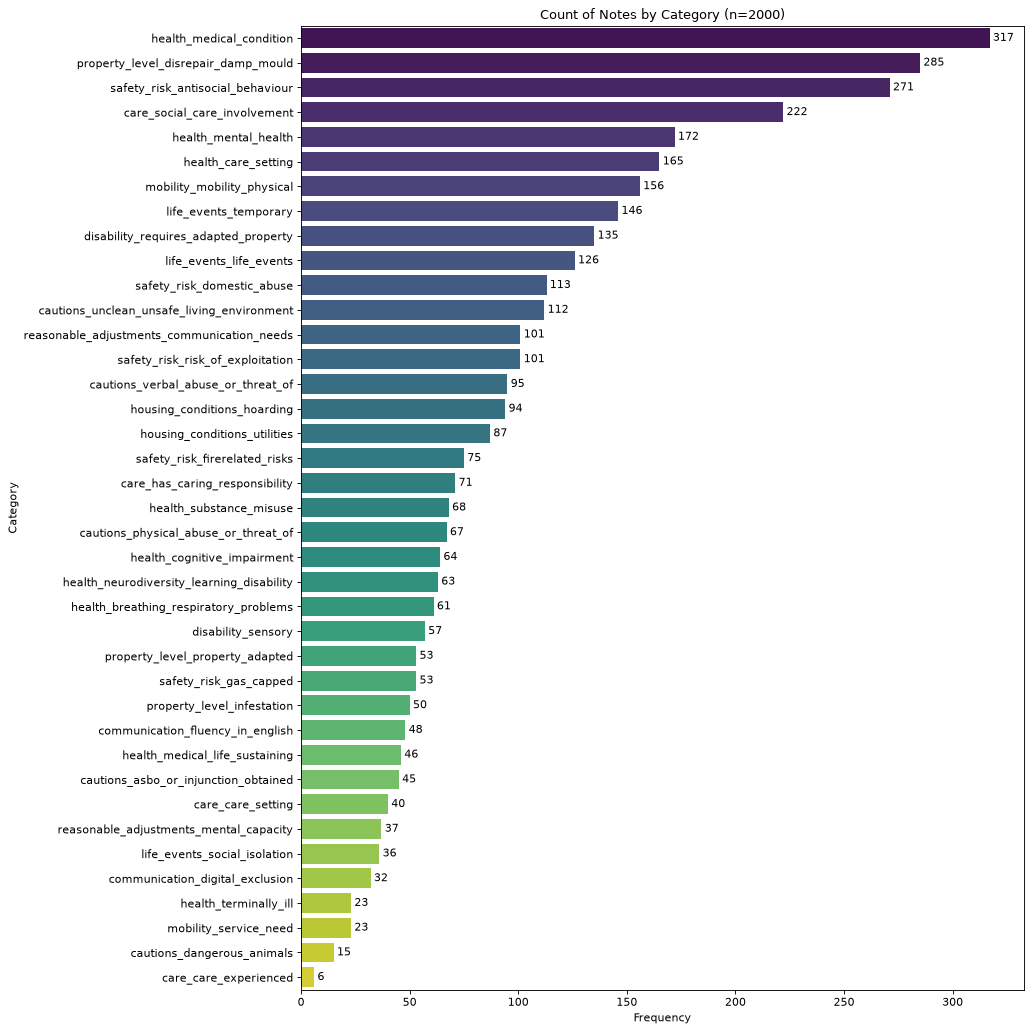

In [ ]:
(irlbl_df, summary, ax) = analyze_category_distribution_from_dict(records, taxonomy, log_scale=False)

display(irlbl_df.style.background_gradient(cmap='Reds', subset=['IRLbl']))
display(summary)
plt.show()

### Display Span Lengths

In [ ]:
from collections import Counter

need_lengths = Counter()
person_lengths = Counter()

for r in records:
    for n in r['needs']:
        if n['label'] == 'property_level_property_adapted':
            need_lengths[len(n['text'])] += 1
    # for p in r['persons']:
    #     person_lengths[len(p['text'])] += 1

need_lengths.most_common()
# pd.Series(person_lengths).plot.hist()

[(8, 14),
 (19, 7),
 (18, 5),
 (14, 5),
 (10, 4),
 (28, 3),
 (20, 3),
 (33, 3),
 (21, 3),
 (9, 3),
 (13, 2),
 (12, 2),
 (15, 2),
 (16, 2),
 (45, 1),
 (24, 1),
 (61, 1),
 (90, 1),
 (40, 1),
 (53, 1),
 (27, 1),
 (34, 1),
 (37, 1),
 (35, 1),
 (22, 1),
 (30, 1)]

## Plot person span relation types

<Axes: >

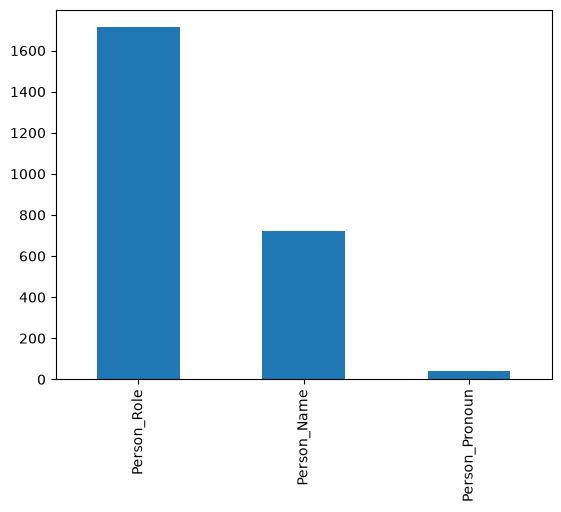

In [ ]:
person_types = Counter()

for r in records:
    relation_entities = set([rel['to'] for rel in r['relations']])
    person_types_in_note = [p['label'] for p in r['persons'] if p['id'] in relation_entities]
    for t in person_types_in_note:
        person_types[t] += 1

pd.Series(person_types).plot.bar()

### Plot relation counts per doc

<Axes: >

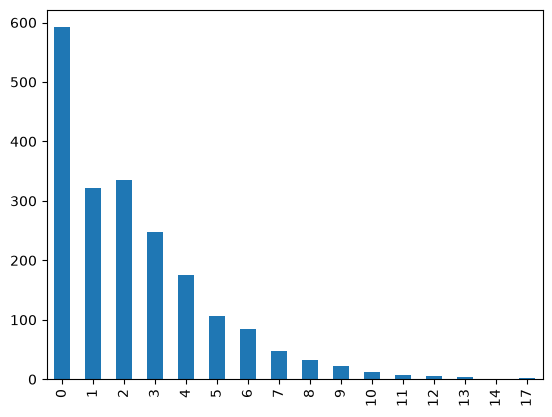

In [ ]:
relation_counts = Counter()
for r in records:
    relation_counts[len(r["relations"])] += 1

pd.Series(relation_counts).sort_index().plot.bar()

## Get note lengths (tokens)

Token indices sequence length is longer than the specified maximum sequence length for this model (516 > 512). Running this sequence through the model will result in indexing errors


516
[ 90.   225.   267.15 434.03]


<Axes: ylabel='Frequency'>

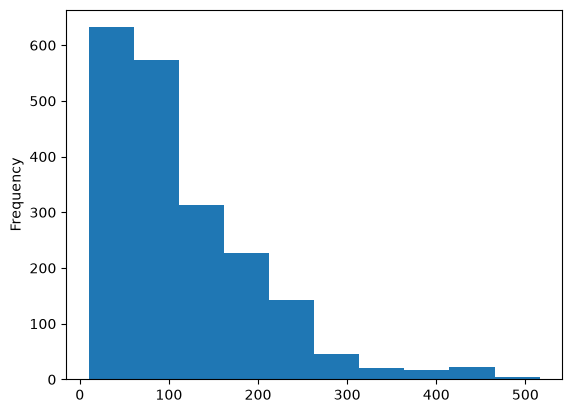

In [ ]:
tokenizer = AutoTokenizer.from_pretrained('distilbert-base-uncased')

lengths = [
    len(tokenizer(r["text"])["input_ids"])
    for r in records
]

print(max(lengths))
print(np.percentile(lengths, [50, 90, 95, 99]))

pd.Series(lengths).plot.hist()

In [ ]:
truncated = 0
max_length = 256

for r in records:
    ids = tokenizer(
        r["text"],
        truncation=True,
        max_length=max_length
    )["input_ids"]

    full = tokenizer(r["text"])["input_ids"]

    if len(ids) < len(full):
        truncated += 1

print(truncated, "/", len(records))

115 / 2000


In [ ]:
lost = 0
total = 0

for r in records:
    encoded = tokenizer(
        r["text"],
        truncation=True,
        max_length=256,
        return_offsets_mapping=True
    )

    valid_offsets = [
        (s, e) for s, e in encoded["offset_mapping"]
        if s != e
    ]

    cutoff = valid_offsets[-1][1]

    for need in r["needs"]:
        if need["end"] > cutoff:
            lost += 1
        total += 1

print(lost, "/", total)

171 / 5582


### Combine person labels

In [ ]:
for r in records:
    for p in r['persons']:
        p['label'] = 'person_ref'

## Combine Low Prevalence Categories

In [ ]:
MERGE_MAP = {
    "care_care_experienced": "life_events_life_events",
    "cautions_dangerous_animals": "safety_risk_antisocial_behaviour",
    "mobility_service_need": "mobility_mobility_physical",
    "health_medical_life_sustaining": "health_terminally_ill",
    "reasonable_adjustments_mental_capacity": "reasonable_adjustments_communication_needs",
    "life_events_social_isolation": "life_events_life_events",
}


In [ ]:
taxonomy_v3 = taxonomy.copy()
taxonomy_v3['values_hint'] = taxonomy_v3['values_hint'].apply(ast.literal_eval)

# Merge regexes & values_hint to the new label
for old_label, new_label in MERGE_MAP.items():
    old_row = taxonomy_v3[taxonomy_v3['cat_label'] == old_label].iloc[0]
    new_idx = taxonomy_v3[taxonomy_v3['cat_label'] == new_label].index[0]

    old_regex = old_row['regex'].strip()
    new_regex = taxonomy_v3.at[new_idx, 'regex'].strip()
    taxonomy_v3.at[new_idx, 'regex'] = f"(?:{old_regex})|(?:{new_regex})"
    print(f"Merged regex: '{old_label}' + '{new_label}' -> combined pattern on '{new_label}' row")

    old_values = old_row['values_hint']
    new_values = taxonomy_v3.at[new_idx, 'values_hint']
    taxonomy_v3.at[new_idx, 'values_hint'] = new_values + old_values
    print(f"Merged value_hint: '{old_values}' + '{new_values}' -> combined on '{new_label}' row")


# Drop old labels & save
labels_to_drop = set(MERGE_MAP.keys())
taxonomy_v3 = taxonomy_v3[~taxonomy_v3['cat_label'].isin(labels_to_drop)].reset_index(drop=True)
taxonomy_v3.to_csv(config.TAXONOMY_V3_PATH, index=False)

config.CAT_LABELS = set(taxonomy_v3.cat_label.to_list())

Merged regex: 'care_care_experienced' + 'life_events_life_events' -> combined pattern on 'life_events_life_events' row
Merged value_hint: '['Care leaver', 'Care experienced (under 25)']' + '['Ex service personnel', 'In prison', 'Left prison']' -> combined on 'life_events_life_events' row
Merged regex: 'cautions_dangerous_animals' + 'safety_risk_antisocial_behaviour' -> combined pattern on 'safety_risk_antisocial_behaviour' row
Merged value_hint: '['Dog', 'Reptile', 'Other']' + '['Perpetrator of harassment', 'Victim of harassment', 'Perpetrator of hate crime', 'Victim of hate crime']' -> combined on 'safety_risk_antisocial_behaviour' row
Merged regex: 'mobility_service_need' + 'mobility_mobility_physical' -> combined pattern on 'mobility_mobility_physical' row
Merged value_hint: '['Unable to answer door', 'Allow time to answer door', 'Prepayment Meter - can’t access', 'Personal Emergency Evaculation Plan (PEEP)']' + '['Frail', 'History of falls', 'Limited mobility: Zimmer frame', 'Limit

In [ ]:
records_v2 = []

# Loop through and reokace labels
for record in records:
    new_record = record.copy()
    for ann in new_record.get("needs", []):
        old_label = ann['label']
        if old_label in labels_to_drop:
            new_label = MERGE_MAP.get(old_label)
            ann['label'] = new_label
            print(f"Replaced label '{old_label}' with '{new_label}' in note {new_record['id']}.")
    records_v2.append(new_record)

Replaced label 'life_events_social_isolation' with 'life_events_life_events' in note d02ee213-1785-1603-e09f-e518b5a8954d.
Replaced label 'life_events_social_isolation' with 'life_events_life_events' in note d02ee213-1785-1603-e09f-e518b5a8954d.
Replaced label 'care_care_experienced' with 'life_events_life_events' in note ea4dfca4-2217-d79a-1006-237e50da9a6e.
Replaced label 'care_care_experienced' with 'life_events_life_events' in note c3c542ef-c255-b431-78df-1a85e12fc2a5.
Replaced label 'life_events_social_isolation' with 'life_events_life_events' in note 78548da4-ee06-4dc0-907c-de6b18422a06.
Replaced label 'mobility_service_need' with 'mobility_mobility_physical' in note 7bb4875e-96e1-47e0-94bb-512317b945a5.
Replaced label 'reasonable_adjustments_mental_capacity' with 'reasonable_adjustments_communication_needs' in note 5c4a7f84-d8d5-f17a-8ebf-7fcb3df260ba.
Replaced label 'health_medical_life_sustaining' with 'health_terminally_ill' in note 6e59bfef-6511-085c-df46-968a4daf411a.
Repla

,label,frequency,IRLbl
0,health_medical_condition,317,1.000000
1,property_level_disrepair_damp_mould,285,1.112281
2,safety_risk_antisocial_behaviour,281,1.128114
3,care_social_care_involvement,222,1.427928
4,health_mental_health,172,1.843023
5,mobility_mobility_physical,171,1.853801
6,health_care_setting,165,1.921212
7,life_events_life_events,162,1.956790
8,life_events_temporary,146,2.171233
9,reasonable_adjustments_communication_needs,135,2.348148


,Metric,Value
0,MeanIR,3.99
1,MaxIR,9.91
2,CVIR,0.54


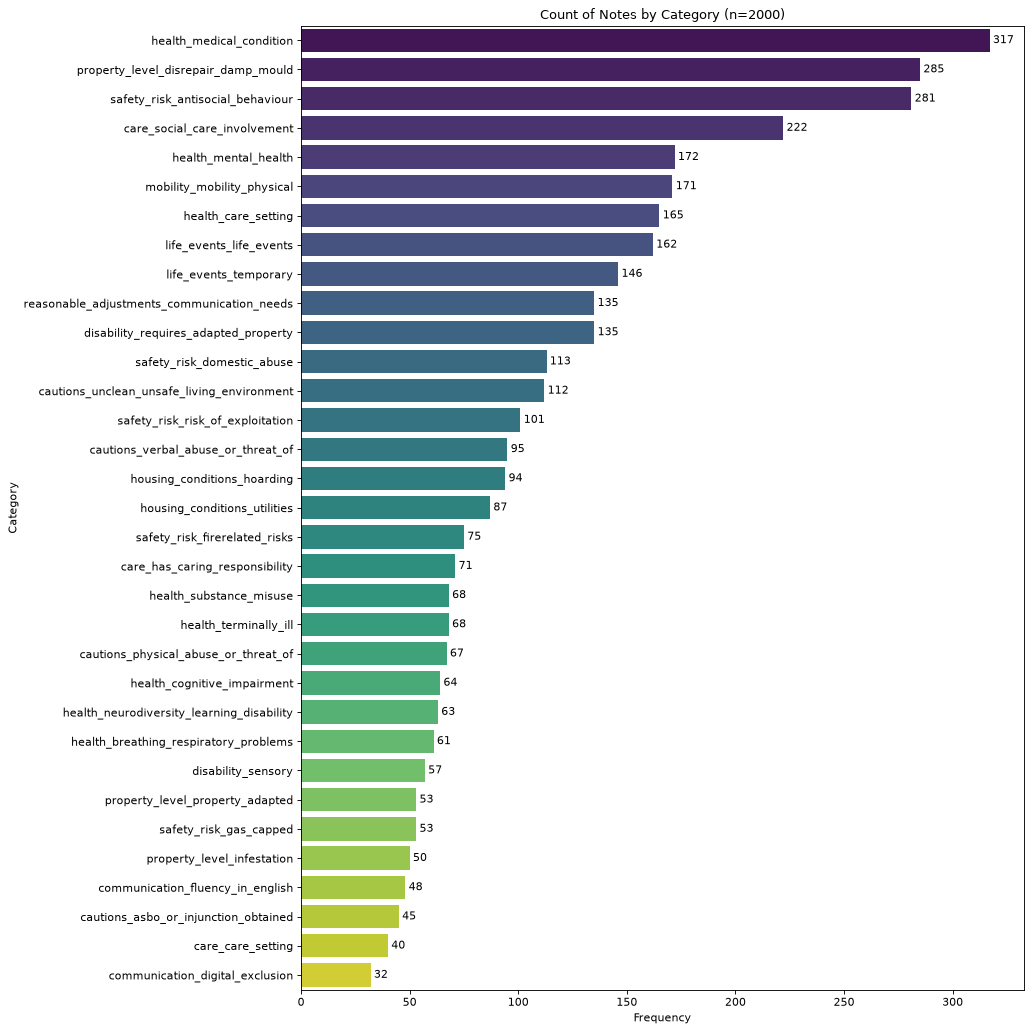

In [ ]:
(irlbl_df, summary, ax) = analyze_category_distribution_from_dict(records_v2, taxonomy_v3, log_scale=False)

display(irlbl_df.style.background_gradient(cmap='Reds', subset=['IRLbl']))
display(summary)
plt.show()

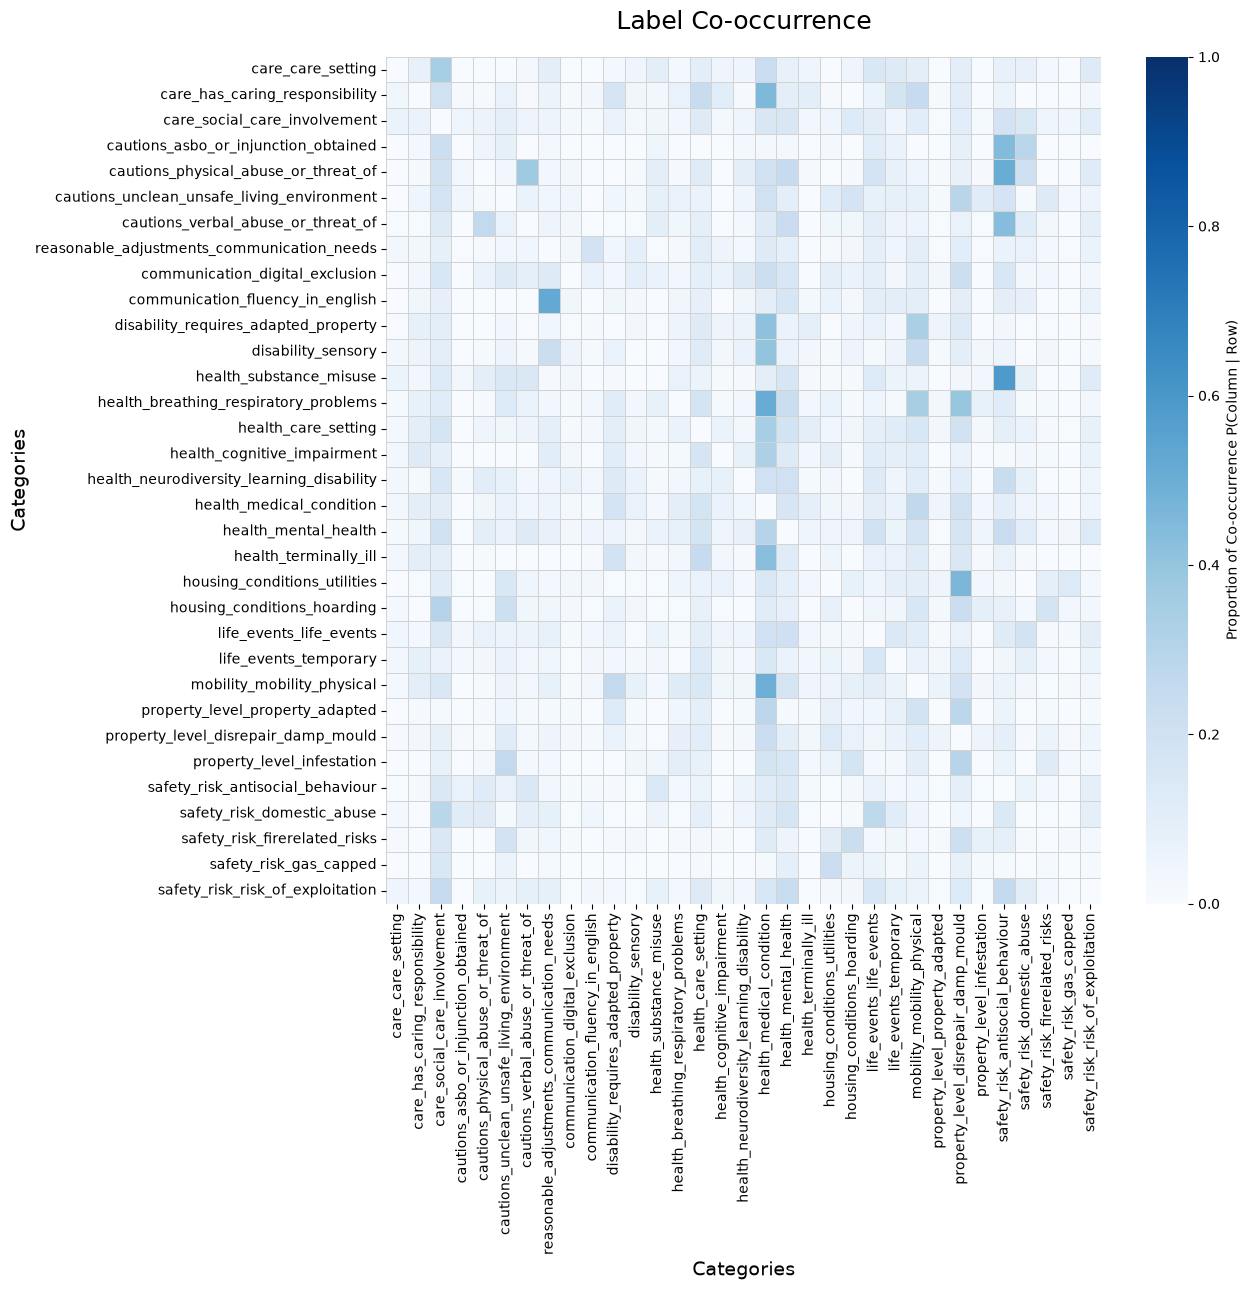

<Axes: title={'center': 'Label Co-occurrence'}, xlabel='Categories', ylabel='Categories'>

In [ ]:
plot_cooccurrence_heatmap(records_v2, taxonomy_v3)

## Span Lengths

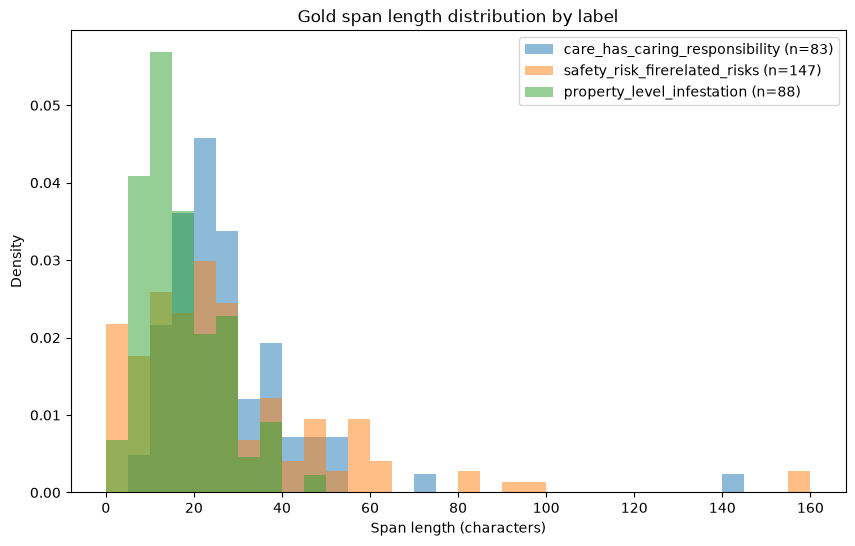

care_has_caring_responsibility: n=83, median=24, max=140
safety_risk_firerelated_risks: n=147, median=22, max=158
property_level_infestation: n=88, median=13, max=46


In [ ]:
import matplotlib.pyplot as plt

# Labels to compare — edit this list as needed.
LABELS_TO_PLOT = [
    "care_has_caring_responsibility",
    "safety_risk_firerelated_risks",
    "property_level_infestation",
]

lengths_by_label = {label: [] for label in LABELS_TO_PLOT}
for r in records_v2:
    for n in r["needs"]:
        if n["label"] in lengths_by_label:
            lengths_by_label[n["label"]].append(len(n["text"]))

fig, ax = plt.subplots(figsize=(10, 6))
max_len = max(length for lengths in lengths_by_label.values() for length in lengths)
bins = range(0, max_len + 5, 5)  # 5-char bins, adjust if too coarse/fine

for label, lengths in lengths_by_label.items():
    ax.hist(lengths, bins=bins, alpha=0.5, label=f"{label} (n={len(lengths)})", density=True)

ax.set_xlabel("Span length (characters)")
ax.set_ylabel("Density")
ax.set_title("Gold span length distribution by label")
ax.legend()
plt.show()

# Raw counts too, since density=True hides absolute sample size differences.
for label, lengths in lengths_by_label.items():
    print(f"{label}: n={len(lengths)}, median={sorted(lengths)[len(lengths) // 2]}, max={max(lengths)}")

## Save as JSON

In [ ]:
# Dump all
with open(config.OUTPUT_PATH, "w", encoding='utf-8') as f:
    json.dump(records_v2, f, indent=4, default=str)
